In [56]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/brazilian-ecommerce/olist_customers_dataset.csv
/kaggle/input/brazilian-ecommerce/olist_sellers_dataset.csv
/kaggle/input/brazilian-ecommerce/olist_order_reviews_dataset.csv
/kaggle/input/brazilian-ecommerce/olist_order_items_dataset.csv
/kaggle/input/brazilian-ecommerce/olist_products_dataset.csv
/kaggle/input/brazilian-ecommerce/olist_geolocation_dataset.csv
/kaggle/input/brazilian-ecommerce/product_category_name_translation.csv
/kaggle/input/brazilian-ecommerce/olist_orders_dataset.csv
/kaggle/input/brazilian-ecommerce/olist_order_payments_dataset.csv


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

cust = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_customers_dataset.csv')
geoloc = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_geolocation_dataset.csv')
item = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_order_items_dataset.csv')
payment = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_order_payments_dataset.csv')
review = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_order_reviews_dataset.csv')
orders = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_orders_dataset.csv')
products = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_products_dataset.csv')
seller = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_sellers_dataset.csv')
productCategoryTranslation = pd.read_csv('/kaggle/input/brazilian-ecommerce/product_category_name_translation.csv')

print("DataSet Downloaded")

DataSet Downloaded


In [58]:
print("=== DATASET OVERVIEW ===\n")
print(f"Customer:{cust.shape}")
print(f"Geo Location:{geoloc.shape}")
print(f"Items:{item.shape}")
print(f"Payments:{payment.shape}")
print(f"Review:{review.shape}")
print(f"Order:{orders.shape}")
print(f"Product:{products.shape}")
print(f"Seller:{seller.shape}")
print(f"product Category Translation:{productCategoryTranslation.shape}")


=== DATASET OVERVIEW ===

Customer:(99441, 5)
Geo Location:(1000163, 5)
Items:(112650, 7)
Payments:(103886, 5)
Review:(99224, 7)
Order:(99441, 8)
Product:(32951, 9)
Seller:(3095, 4)
product Category Translation:(71, 2)


In [59]:
print("=== DATA QUALITY CHECK ===\n")
print("MISSING VALUES:")
for df_name, df in [('customer',cust),('orders',orders),('Geo Location',geoloc),('items',item),('Payments',payment),('Reviews',review),('Product',products),('Seller',seller),('product Category Translation',productCategoryTranslation)]:
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(f"\n{df_name.upper()}:")
        print(missing[missing>0])

print("\nDUPLICATES:")
print(f"Orders duplicates: {orders.duplicated().sum()}")
print(f"Customers duplicates: {cust.duplicated().sum()}")
print(f"Order Items duplicates: {item.duplicated().sum()}")
print(f"Order Reviews duplicates: {review.duplicated().sum()}")
print(f"Products duplicates: {products.duplicated().sum()}")
print(f"Sellers duplicates: {seller.duplicated().sum()}")

=== DATA QUALITY CHECK ===

MISSING VALUES:

ORDERS:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

REVIEWS:
review_comment_title      87656
review_comment_message    58247
dtype: int64

PRODUCT:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

DUPLICATES:
Orders duplicates: 0
Customers duplicates: 0
Order Items duplicates: 0
Order Reviews duplicates: 0
Products duplicates: 0
Sellers duplicates: 0


In [60]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

review['review_creation_date'] = pd.to_datetime(review['review_creation_date'])

print("Date columns converted to datetime format")
print(f"\nOrders date range: {orders['order_purchase_timestamp'].min()} to {orders['order_purchase_timestamp'].max()}")


Date columns converted to datetime format

Orders date range: 2016-09-04 21:15:19 to 2018-10-17 17:30:18


In [61]:
orders['order_delivered_customer_date'] = orders['order_delivered_customer_date'].fillna(
    orders['order_estimated_delivery_date']
)
review_clean = review.dropna(subset=['review_score'])

print("Missing values handled")
print(f"Order reviews with scores: {len(review_clean)} / {len(review)}")
print(f"Null values in orders after cleaning: {orders.isnull().sum().sum()}")

Missing values handled
Order reviews with scores: 99224 / 99224
Null values in orders after cleaning: 1943


In [62]:
analysis = orders.copy()
analysis = analysis.merge(cust,on='customer_id',how='left')
analysis = analysis.merge(item,on='order_id',how='left')
analysis = analysis.merge(products,on='product_id',how='left')
analysis = analysis.merge(review,on='order_id',how='left')
analysis = analysis.merge(products,on='product_id',how='left')
analysis = analysis.merge(payment,on='order_id',how='left')
analysis = analysis.merge(seller,on='seller_id',how='left', suffixes=('_customer','_seller'))
# analysis = analysis.merge(productCategoryTranslation,on='product_category_name_y',how='left')
analysis = analysis.merge(
    productCategoryTranslation,
    left_on='product_category_name_y',
    right_on='product_category_name',
    how='left'
)
analysis.drop(columns=['product_category_name'], inplace=True)
print("✓ All data merged successfully!")
print(f"Final analysis table shape: {analysis.shape}")
print(f"Number of columns: {len(analysis.columns)}")
print(f"\nColumns available:\n{list(analysis.columns)}")

✓ All data merged successfully!
Final analysis table shape: (119143, 48)
Number of columns: 48

Columns available:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name_x', 'product_name_lenght_x', 'product_description_lenght_x', 'product_photos_qty_x', 'product_weight_g_x', 'product_length_cm_x', 'product_height_cm_x', 'product_width_cm_x', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'product_category_name_y', 'product_name_lenght_y', 'product_description_lenght_y', 'product_photos_qty_y', 'product_weight_g_y', 'product_length_cm_y', 'product_height_cm_y', 'product_wid

In [63]:
# Calculate delivery metrics
analysis['delivery_days'] = (analysis['order_delivered_customer_date'] - analysis['order_purchase_timestamp']).dt.days
analysis['estimated_days'] = (analysis['order_estimated_delivery_date'] - analysis['order_purchase_timestamp']).dt.days
analysis['delivery_delay_days'] = analysis['delivery_days'] - analysis['estimated_days']
analysis['delivery_on_time'] = (analysis['order_delivered_customer_date'] <= analysis['order_estimated_delivery_date']).astype(int)

# Extract time-based features
analysis['order_month'] = analysis['order_purchase_timestamp'].dt.to_period('M')
analysis['order_date'] = analysis['order_purchase_timestamp'].dt.date
analysis['order_year_month'] = analysis['order_purchase_timestamp'].dt.strftime('%Y-%m')

# Review score numeric conversion
analysis['review_score_numeric'] = pd.to_numeric(analysis['review_score'], errors='coerce')

print("✓ Key metrics calculated")
print(f"\nDelivery on-time rate: {analysis['delivery_on_time'].mean()*100:.1f}%")
print(f"Average delivery days: {analysis['delivery_days'].mean():.1f} days")
print(f"Average estimated days: {analysis['estimated_days'].mean():.1f} days")
print(f"Average review score: {analysis['review_score_numeric'].mean():.2f} / 5.0")


✓ Key metrics calculated

Delivery on-time rate: 92.4%
Average delivery days: 12.4 days
Average estimated days: 23.5 days
Average review score: 4.02 / 5.0


In [64]:
print("=== SUMMARY STATISTICS ===\n")

print("ORDERS OVERVIEW:")
print(f"Total Orders: {orders['order_id'].nunique()}")
print(f"Total Customers: {cust['customer_id'].nunique()}")
print(f"Date Range: {orders['order_purchase_timestamp'].min().date()} to {orders['order_purchase_timestamp'].max().date()}")
print(f"Total Revenue: $ {payment['payment_value'].sum():,.0f}")
print(f"Average Order Value: $ {payment['payment_value'].mean():,.0f}")
print(f"\nOrder Status Distribution:")
print(orders['order_status'].value_counts())

print("\n\nREVIEW SCORES OVERVIEW:")
print(review['review_score'].describe())
print(f"\nReview Score Distribution:")
print(review['review_score'].value_counts().sort_index())

print("\n\nPRICING OVERVIEW:")
print(item['price'].describe())

print("\n\nDELIVERY METRICS:")
print(f"Average delivery days: {analysis['delivery_days'].mean():.1f}")
print(f"Median delivery days: {analysis['delivery_days'].median():.0f}")
print(f"On-time delivery %: {analysis['delivery_on_time'].mean()*100:.1f}%")

=== SUMMARY STATISTICS ===

ORDERS OVERVIEW:
Total Orders: 99441
Total Customers: 99441
Date Range: 2016-09-04 to 2018-10-17
Total Revenue: $ 16,008,872
Average Order Value: $ 154

Order Status Distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


REVIEW SCORES OVERVIEW:
count    99224.000000
mean         4.086421
std          1.347579
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_score, dtype: float64

Review Score Distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


PRICING OVERVIEW:
count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: fl

In [65]:
print("=== INSIGHT 1: PRODUCT CATEGORY PERFORMANCE ===\n")

category_performance = analysis.groupby('product_category_name_english').agg({
    'review_score': ['mean', 'count'],
    'payment_value': 'sum',
    'order_id': 'count'
}).round(2)

category_performance.columns = ['avg_review_score', 'review_count', 'total_revenue', 'order_count']
category_performance = category_performance.sort_values('order_count', ascending=False)

print(category_performance.head(15))

print("\n\nTOP 5 CATEGORIES BY REVIEW SCORE (min 50 reviews):")
top_reviewed = category_performance[category_performance['review_count'] >= 50].sort_values('avg_review_score', ascending=False)
print(top_reviewed.head(5))


print("\n\nBOTTOM 5 CATEGORIES BY REVIEW SCORE (min 50 reviews):")
bottom_reviewed = category_performance[category_performance['review_count'] >= 50].sort_values('avg_review_score', ascending=True)
print(bottom_reviewed.head(5))


=== INSIGHT 1: PRODUCT CATEGORY PERFORMANCE ===

                               avg_review_score  review_count  total_revenue  \
product_category_name_english                                                  
bed_bath_table                             3.89         11847     1743998.80   
health_beauty                              4.14          9947     1662963.59   
sports_leisure                             4.11          8942     1400223.07   
furniture_decor                            3.91          8743     1443963.61   
computers_accessories                      3.94          8105     1599481.06   
housewares                                 4.06          7331     1097900.09   
watches_gifts                              4.02          6161     1430553.48   
telephony                                  3.95          4692      487189.71   
garden_tools                               4.02          4558      840721.59   
auto                                       4.06          4356      8550

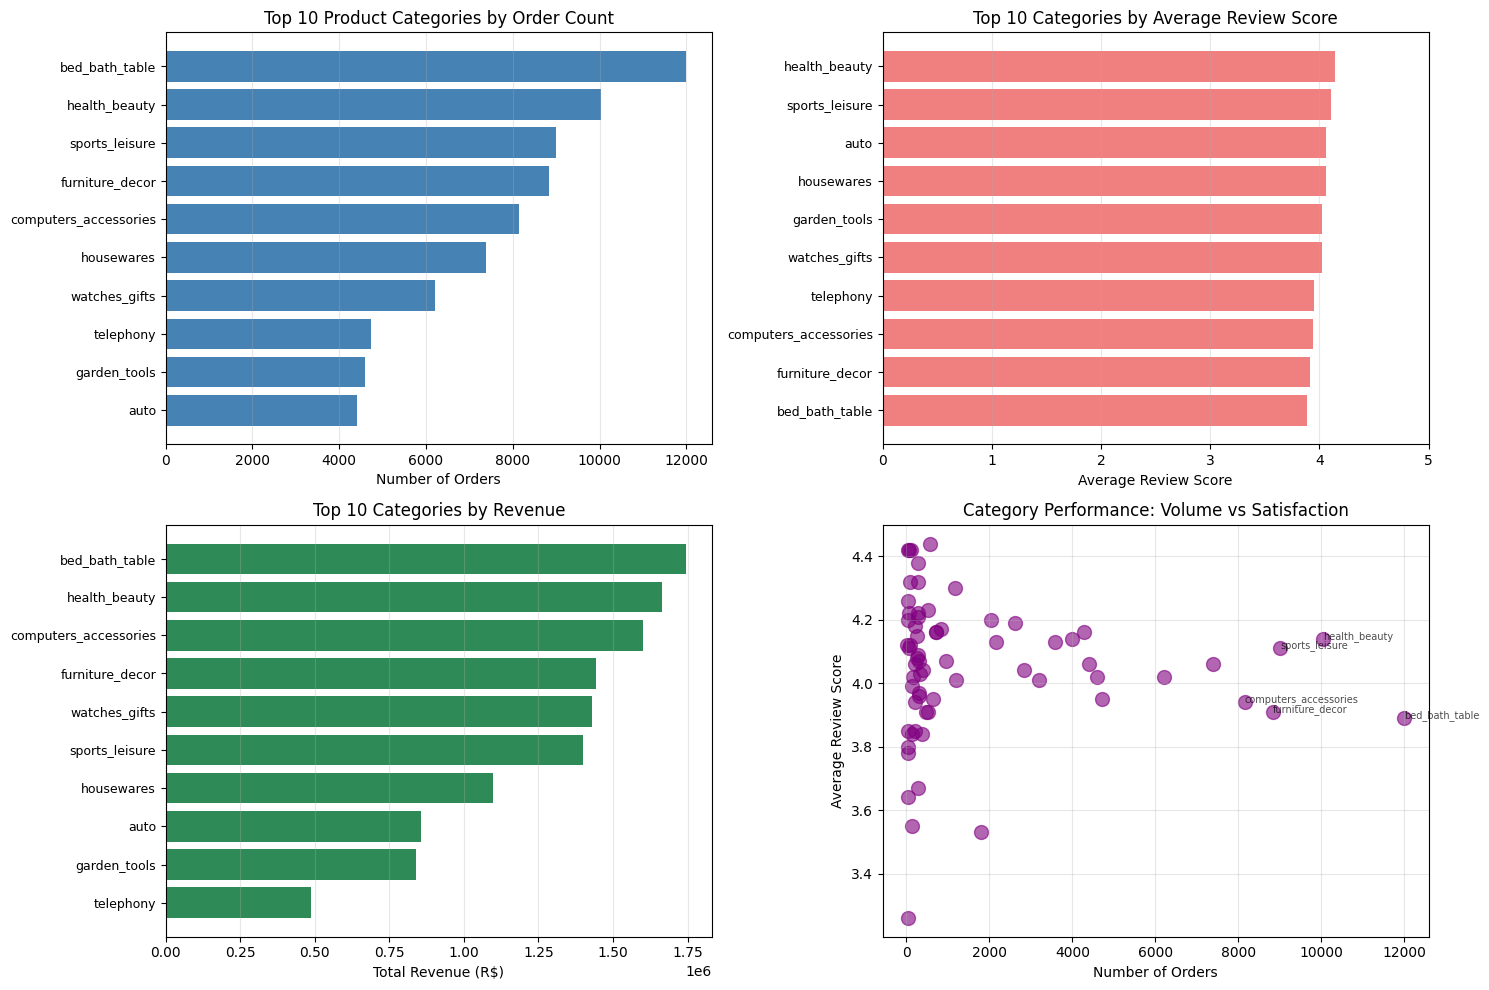

✓ Category performance visualizations created


In [66]:
# Product category visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Top 10 categories by order count
top_10 = category_performance.head(10).sort_values('order_count', ascending=True)
axes[0, 0].barh(range(len(top_10)), top_10['order_count'], color='steelblue')
axes[0, 0].set_yticks(range(len(top_10)))
axes[0, 0].set_yticklabels(top_10.index, fontsize=9)
axes[0, 0].set_xlabel('Number of Orders')
axes[0, 0].set_title('Top 10 Product Categories by Order Count')
axes[0, 0].grid(axis='x', alpha=0.3)

# Plot 2: Average review score by category (top 10)
top_10_reviews = category_performance[category_performance['review_count'] >= 20].head(10).sort_values('avg_review_score', ascending=True)
axes[0, 1].barh(range(len(top_10_reviews)), top_10_reviews['avg_review_score'], color='lightcoral')
axes[0, 1].set_yticks(range(len(top_10_reviews)))
axes[0, 1].set_yticklabels(top_10_reviews.index, fontsize=9)
axes[0, 1].set_xlabel('Average Review Score')
axes[0, 1].set_xlim(0, 5)
axes[0, 1].set_title('Top 10 Categories by Average Review Score')
axes[0, 1].grid(axis='x', alpha=0.3)

# Plot 3: Revenue by category (top 10)
top_revenue = category_performance.head(10).sort_values('total_revenue', ascending=True)
axes[1, 0].barh(range(len(top_revenue)), top_revenue['total_revenue'], color='seagreen')
axes[1, 0].set_yticks(range(len(top_revenue)))
axes[1, 0].set_yticklabels(top_revenue.index, fontsize=9)
axes[1, 0].set_xlabel('Total Revenue (R$)')
axes[1, 0].set_title('Top 10 Categories by Revenue')
axes[1, 0].grid(axis='x', alpha=0.3)

# Plot 4: Scatter - Review Score vs Order Count
scatter_data = category_performance[category_performance['review_count'] >= 20]
axes[1, 1].scatter(scatter_data['order_count'], scatter_data['avg_review_score'], s=100, alpha=0.6, color='purple')
axes[1, 1].set_xlabel('Number of Orders')
axes[1, 1].set_ylabel('Average Review Score')
axes[1, 1].set_title('Category Performance: Volume vs Satisfaction')
axes[1, 1].grid(alpha=0.3)

# Add category labels for top outliers
for idx in scatter_data.nlargest(5, 'order_count').index:
    axes[1, 1].annotate(idx, (scatter_data.loc[idx, 'order_count'], scatter_data.loc[idx, 'avg_review_score']), 
                       fontsize=7, alpha=0.7)

plt.tight_layout()
plt.show()

print("✓ Category performance visualizations created")


In [75]:
print("=== INSIGHT 2: DELIVERY PERFORMANCE vs REVIEW SCORES ===\n")

# Compare on-time vs late deliveries
delivery_impact = analysis.groupby('delivery_on_time').agg({
    'review_score_numeric': ['mean', 'count', 'std'],
    'payment_value': 'mean'
}).round(2)

delivery_impact.columns = ['avg_review_score', 'order_count', 'score_std', 'avg_order_value']
print(delivery_impact)

# Delivery delay analysis
print("\n\nDELIVERY DELAY IMPACT:")
delay_analysis = analysis.groupby(pd.cut(analysis['delivery_delay_days'], bins=[-float('inf'), -7, -3, 0, 3, 7, float('inf')], 
                                         labels=['7+ days early', '3-7 days early', '0-3 days early', '0-3 days late', '3-7 days late', '7+ days late']),observed=False).agg({
    'review_score_numeric': ['mean', 'count'],
    'order_id': 'count'
}).round(2)

delay_analysis.columns = ['avg_review_score', 'review_count', 'order_count']
print(delay_analysis)

print("\n\nKEY FINDING:")
on_time_avg = analysis[analysis['delivery_on_time'] == 1]['review_score_numeric'].mean()
late_avg = analysis[analysis['delivery_on_time'] == 0]['review_score_numeric'].mean()
print(f"On-time delivery avg score: {on_time_avg:.2f} / 5.0")
print(f"Late delivery avg score: {late_avg:.2f} / 5.0")
print(f"Difference: {on_time_avg - late_avg:.2f} points")


=== INSIGHT 2: DELIVERY PERFORMANCE vs REVIEW SCORES ===

                  avg_review_score  order_count  score_std  avg_order_value
delivery_on_time                                                           
0                             2.55         8863       1.66           178.89
1                             4.13       109283       1.31           172.23


DELIVERY DELAY IMPACT:
                     avg_review_score  review_count  order_count
delivery_delay_days                                             
7+ days early                    4.22         87858        88405
3-7 days early                   4.16         13517        13592
0-3 days early                   3.17          8500         8676
0-3 days late                    3.57          2716         2746
3-7 days late                    2.21          2010         2075
7+ days late                     1.71          3545         3649


KEY FINDING:
On-time delivery avg score: 4.13 / 5.0
Late delivery avg score: 2.55 / 5.0
Dif

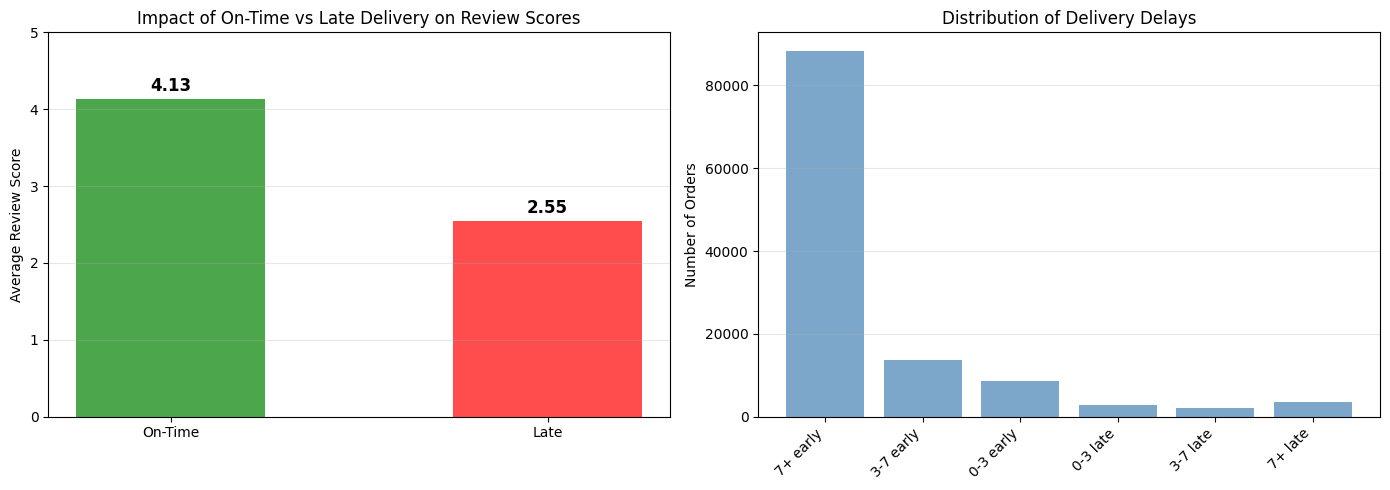

✓ Delivery impact visualizations created


In [76]:
#Delivery Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: On-time vs Late delivery scores
delivery_labels = ['On-Time', 'Late']
delivery_scores = [on_time_avg, late_avg]
colors = ['green', 'red']

axes[0].bar(delivery_labels, delivery_scores, color=colors, alpha=0.7, width=0.5)
axes[0].set_ylabel('Average Review Score')
axes[0].set_ylim(0, 5)
axes[0].set_title('Impact of On-Time vs Late Delivery on Review Scores')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(delivery_scores):
    axes[0].text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=12, fontweight='bold')

# Plot 2: Delivery delay distribution
delay_bins = pd.cut(analysis['delivery_delay_days'], bins=[-float('inf'), -7, -3, 0, 3, 7, float('inf')], 
                    labels=['7+ early', '3-7 early', '0-3 early', '0-3 late', '3-7 late', '7+ late'])
delay_counts = delay_bins.value_counts().sort_index()

axes[1].bar(range(len(delay_counts)), delay_counts.values, color='steelblue', alpha=0.7)
axes[1].set_xticks(range(len(delay_counts)))
axes[1].set_xticklabels(delay_counts.index, rotation=45, ha='right')
axes[1].set_ylabel('Number of Orders')
axes[1].set_title('Distribution of Delivery Delays')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Delivery impact visualizations created")


In [77]:
print("=== INSIGHT 3: GEOGRAPHIC ANALYSIS ===\n")

geographic = analysis.groupby('customer_state').agg({
    'order_id': 'count',
    'payment_value': ['sum', 'mean'],
    'review_score_numeric': 'mean',
    'delivery_on_time': 'mean'
}).round(2)

geographic.columns = ['order_count', 'total_revenue', 'avg_order_value', 'avg_review_score', 'on_time_pct']
geographic = geographic.sort_values('order_count', ascending=False)

print(geographic.head(15))

print("\n\nTOP 5 STATES BY ORDER VOLUME:")
print(geographic.head(5)[['order_count', 'total_revenue', 'avg_review_score']])

print("\n\nTOP 5 STATES BY CUSTOMER SATISFACTION:")
print(geographic.sort_values('avg_review_score', ascending=False).head(5)[['order_count', 'avg_review_score', 'on_time_pct']])

print("\n\nTOP 5 STATES BY ON-TIME DELIVERY:")
print(geographic.sort_values('on_time_pct', ascending=False).head(5)[['order_count', 'on_time_pct', 'avg_review_score']])


=== INSIGHT 3: GEOGRAPHIC ANALYSIS ===

                order_count  total_revenue  avg_order_value  avg_review_score  \
customer_state                                                                  
SP                    50265     7726078.35           153.72              4.11   
RJ                    15518     2795615.67           180.15              3.80   
MG                    13819     2351221.09           170.14              4.07   
RS                     6573     1160175.66           176.51              4.03   
PR                     6043     1079795.49           178.69              4.09   
SC                     4345      801276.45           184.41              3.99   
BA                     4091      805070.98           196.79              3.81   
DF                     2516      438095.32           174.12              3.99   
GO                     2466      520481.65           211.06              3.98   
ES                     2360      408611.64           173.14          

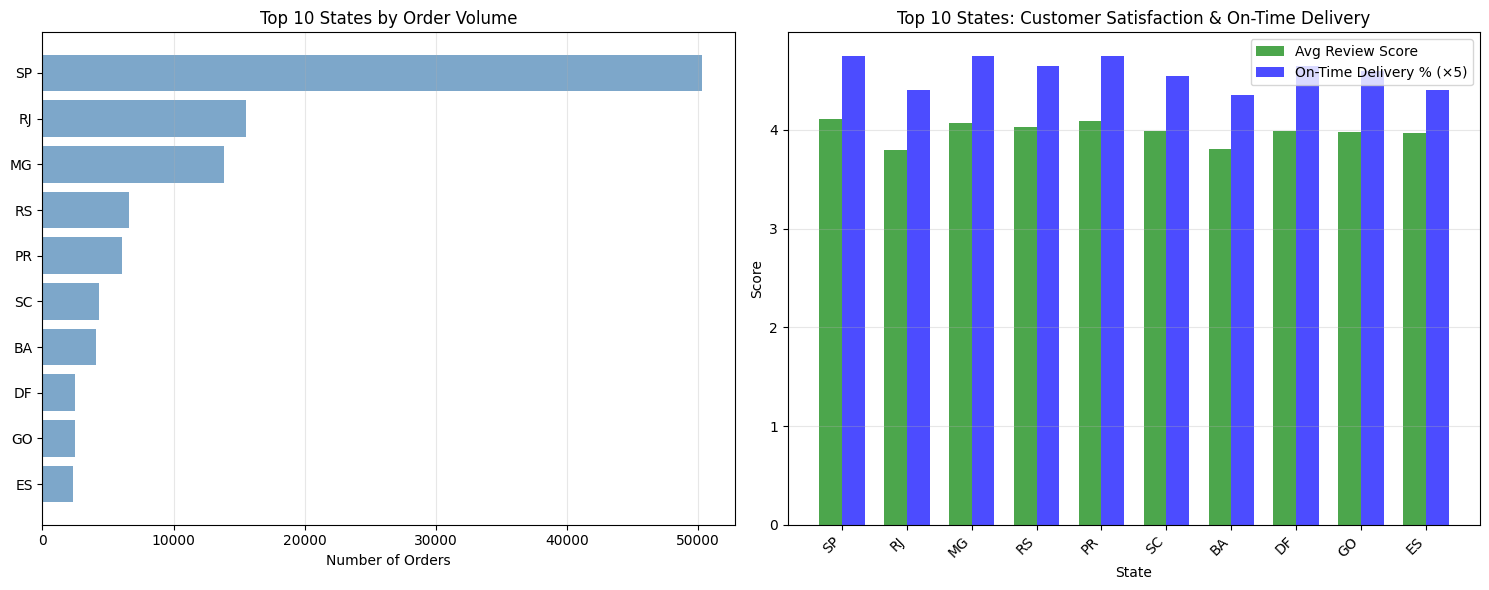

✓ Geographic performance visualizations created


In [78]:
#Geographic graph visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Top 10 states by order count
top_states = geographic.head(10).sort_values('order_count', ascending=True)
axes[0].barh(range(len(top_states)), top_states['order_count'], color='steelblue', alpha=0.7)
axes[0].set_yticks(range(len(top_states)))
axes[0].set_yticklabels(top_states.index)
axes[0].set_xlabel('Number of Orders')
axes[0].set_title('Top 10 States by Order Volume')
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Review score vs on-time delivery by state
top_10_states_full = geographic.head(10)
x_pos = np.arange(len(top_10_states_full))
width = 0.35

axes[1].bar(x_pos - width/2, top_10_states_full['avg_review_score'], width, label='Avg Review Score', color='green', alpha=0.7)
axes[1].bar(x_pos + width/2, top_10_states_full['on_time_pct'] * 5, width, label='On-Time Delivery % (×5)', color='blue', alpha=0.7)
axes[1].set_ylabel('Score')
axes[1].set_xlabel('State')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(top_10_states_full.index, rotation=45, ha='right')
axes[1].set_title('Top 10 States: Customer Satisfaction & On-Time Delivery')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Geographic performance visualizations created")


In [79]:
print("=== INSIGHT 4: SEASONAL TRENDS ===\n")

# Monthly revenue and order trends
monthly_trends = analysis.groupby('order_year_month').agg({
    'payment_value': 'sum',
    'order_id': 'count',
    'review_score_numeric': 'mean'
}).round(2)

monthly_trends.columns = ['total_revenue', 'order_count', 'avg_review_score']
monthly_trends.index = pd.to_datetime(monthly_trends.index)
monthly_trends = monthly_trends.sort_index()

print(monthly_trends)

print("\n\nSEASONAL INSIGHTS:")
print(f"Peak month by revenue: {monthly_trends['total_revenue'].idxmax().strftime('%Y-%m')} (R$ {monthly_trends['total_revenue'].max():,.0f})")
print(f"Peak month by orders: {monthly_trends['order_count'].idxmax().strftime('%Y-%m')} ({monthly_trends['order_count'].max()} orders)")
print(f"Average monthly revenue: R$ {monthly_trends['total_revenue'].mean():,.0f}")
print(f"Average monthly orders: {monthly_trends['order_count'].mean():.0f}")


=== INSIGHT 4: SEASONAL TRENDS ===

                  total_revenue  order_count  avg_review_score
order_year_month                                              
2016-09-01               388.47            7              1.00
2016-10-01             76559.05          401              3.52
2016-12-01                19.62            1              5.00
2017-01-01            190806.27         1035              4.08
2017-02-01            351848.13         2123              4.00
2017-03-01            547769.84         3243              4.04
2017-04-01            512126.52         2878              3.97
2017-05-01            737425.31         4485              4.11
2017-06-01            613777.41         3853              4.12
2017-07-01            749242.84         4949              4.09
2017-08-01            884168.36         5278              4.21
2017-09-01           1030141.97         5186              4.12
2017-10-01           1046083.41         5683              4.03
2017-11-01         

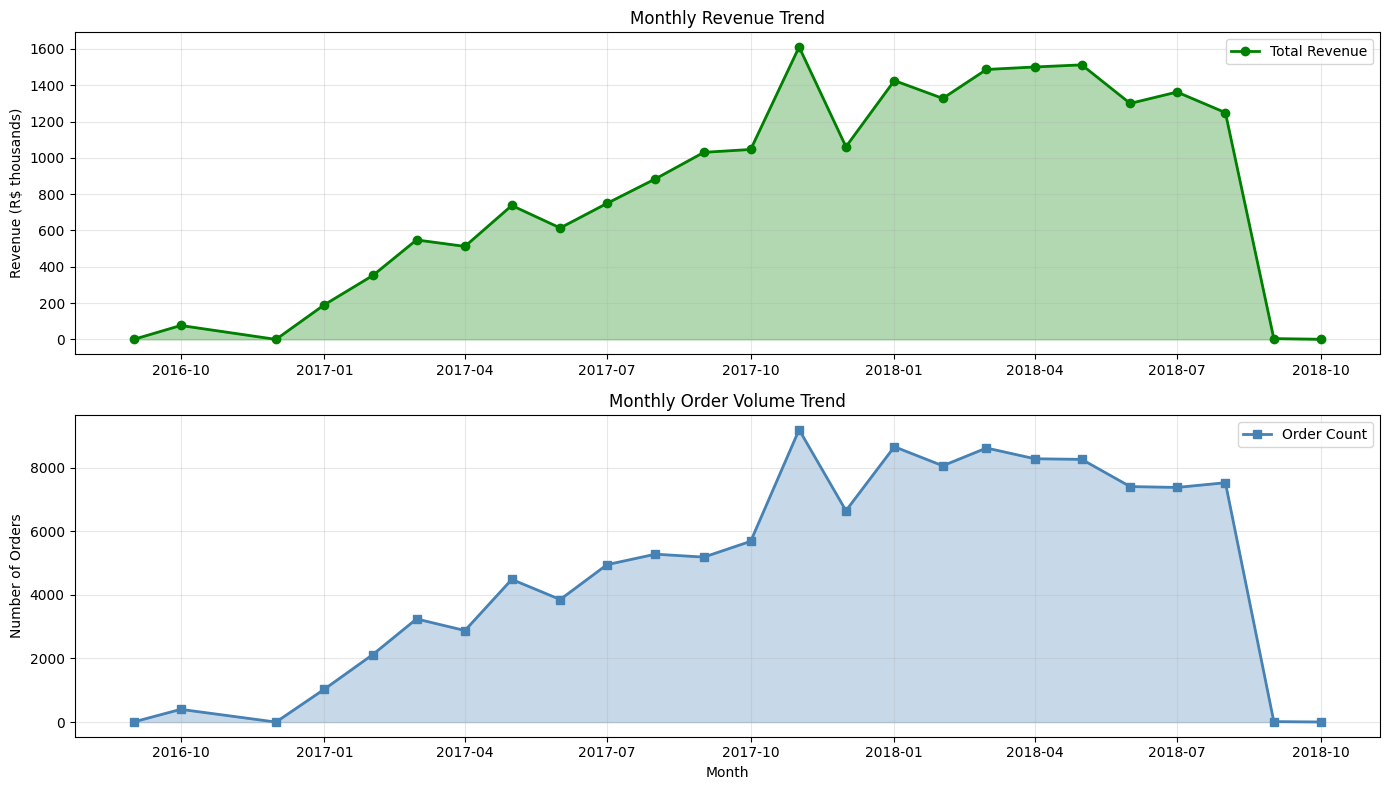

✓ Seasonal trend visualizations created


In [80]:
#Sesonal Trend Visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Monthly revenue trend
axes[0].plot(monthly_trends.index, monthly_trends['total_revenue']/1000, marker='o', linewidth=2, color='green', label='Total Revenue')
axes[0].fill_between(monthly_trends.index, 0, monthly_trends['total_revenue']/1000, alpha=0.3, color='green')
axes[0].set_ylabel('Revenue (R$ thousands)')
axes[0].set_title('Monthly Revenue Trend')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Plot 2: Monthly order count trend
axes[1].plot(monthly_trends.index, monthly_trends['order_count'], marker='s', linewidth=2, color='steelblue', label='Order Count')
axes[1].fill_between(monthly_trends.index, 0, monthly_trends['order_count'], alpha=0.3, color='steelblue')
axes[1].set_ylabel('Number of Orders')
axes[1].set_xlabel('Month')
axes[1].set_title('Monthly Order Volume Trend')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("✓ Seasonal trend visualizations created")


In [81]:
print("=== INSIGHT 5: SELLER PERFORMANCE ===\n")

seller_performance = analysis.groupby('seller_id').agg({
    'order_id': 'count',
    'review_score_numeric': ['mean', 'count'],
    'payment_value': 'sum',
    'delivery_on_time': 'mean'
}).round(2)

seller_performance.columns = ['product_count', 'avg_review_score', 'review_count', 'total_revenue', 'on_time_pct']
seller_performance = seller_performance.sort_values('product_count', ascending=False)

# Filter sellers with at least 50 products sold
active_sellers = seller_performance[seller_performance['product_count'] >= 50]

print("TOP 15 SELLERS BY PRODUCT COUNT (with 50+ products):")
print(active_sellers.head(15))

print("\n\nTOP 10 SELLERS BY REVIEW SCORE (with 50+ products):")
print(active_sellers.sort_values('avg_review_score', ascending=False).head(10))

print("\n\nTOP 10 SELLERS BY REVENUE:")
print(seller_performance.head(10)[['product_count', 'total_revenue', 'avg_review_score']])

print(f"\n\nTOTAL SELLERS: {len(seller_performance)}")
print(f"Active sellers (50+ products): {len(active_sellers)}")
print(f"Average seller products: {seller_performance['product_count'].mean():.1f}")
print(f"Average seller rating: {seller_performance['avg_review_score'].mean():.2f} / 5.0")


=== INSIGHT 5: SELLER PERFORMANCE ===

TOP 15 SELLERS BY PRODUCT COUNT (with 50+ products):
                                  product_count  avg_review_score  \
seller_id                                                           
4a3ca9315b744ce9f8e9374361493884           2155              3.80   
6560211a19b47992c3666cc44a7e94c0           2130              3.91   
1f50f920176fa81dab994f9023523100           2017              3.98   
cc419e0650a3c5ba77189a1882b7556a           1893              4.05   
da8622b14eb17ae2831f4ac5b9dab84a           1662              4.07   
955fee9216a65b617aa5c0531780ce60           1530              4.05   
1025f0e2d44d7041d6cf58b6550e0bfa           1477              3.86   
7c67e1448b00f6e969d365cea6b010ab           1463              3.39   
7a67c85e85bb2ce8582c35f2203ad736           1245              4.23   
ea8482cd71df3c1969d7b9473ff13abc           1240              3.96   
3d871de0142ce09b7081e2b9d1733cb1           1205              4.12   
4869f7a5dfa

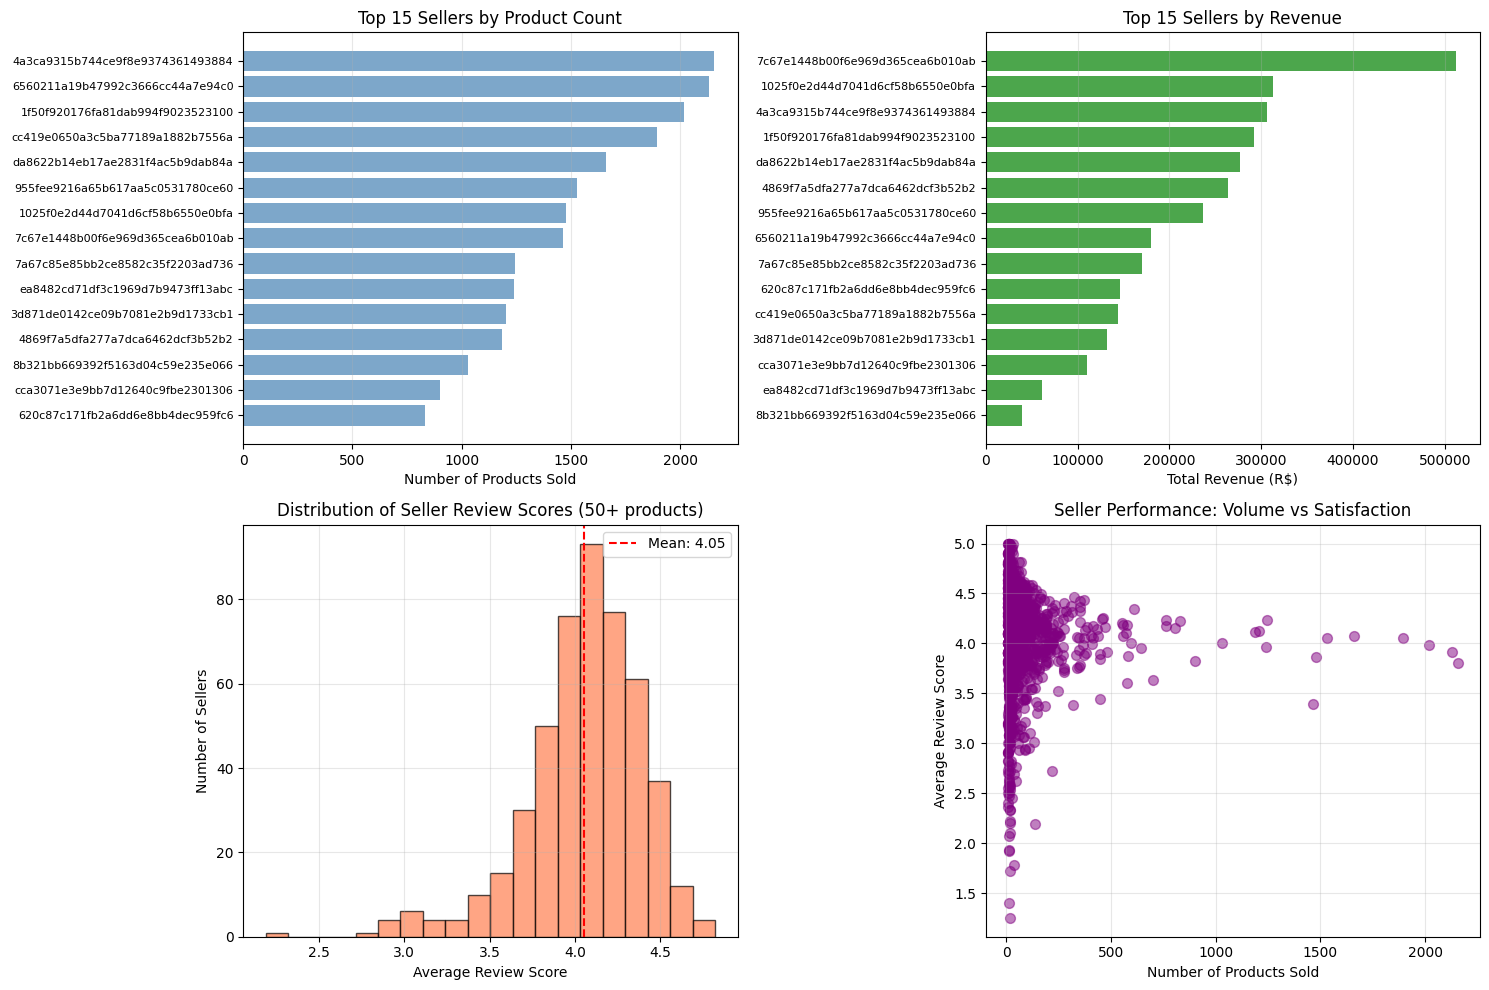

✓ Seller performance visualizations created


In [82]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Top 15 sellers by product count
top_sellers = seller_performance.head(15).sort_values('product_count', ascending=True)
axes[0, 0].barh(range(len(top_sellers)), top_sellers['product_count'], color='steelblue', alpha=0.7)
axes[0, 0].set_yticks(range(len(top_sellers)))
axes[0, 0].set_yticklabels(top_sellers.index, fontsize=8)
axes[0, 0].set_xlabel('Number of Products Sold')
axes[0, 0].set_title('Top 15 Sellers by Product Count')
axes[0, 0].grid(axis='x', alpha=0.3)

# Top 15 sellers by revenue
top_revenue_sellers = seller_performance.head(15).sort_values('total_revenue', ascending=True)
axes[0, 1].barh(range(len(top_revenue_sellers)), top_revenue_sellers['total_revenue'], color='green', alpha=0.7)
axes[0, 1].set_yticks(range(len(top_revenue_sellers)))
axes[0, 1].set_yticklabels(top_revenue_sellers.index, fontsize=8)
axes[0, 1].set_xlabel('Total Revenue (R$)')
axes[0, 1].set_title('Top 15 Sellers by Revenue')
axes[0, 1].grid(axis='x', alpha=0.3)

# Review score distribution
axes[1, 0].hist(active_sellers['avg_review_score'].dropna(), bins=20, color='coral', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Average Review Score')
axes[1, 0].set_ylabel('Number of Sellers')
axes[1, 0].set_title('Distribution of Seller Review Scores (50+ products)')
axes[1, 0].axvline(active_sellers['avg_review_score'].mean(), color='red', linestyle='--', label=f"Mean: {active_sellers['avg_review_score'].mean():.2f}")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Scatter: Product count vs Review score
scatter_data = seller_performance[seller_performance['product_count'] >= 10]
axes[1, 1].scatter(scatter_data['product_count'], scatter_data['avg_review_score'], alpha=0.5, s=50, color='purple')
axes[1, 1].set_xlabel('Number of Products Sold')
axes[1, 1].set_ylabel('Average Review Score')
axes[1, 1].set_title('Seller Performance: Volume vs Satisfaction')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Seller performance visualizations created")


In [84]:
print("="*80)
print("EXECUTIVE SUMMARY - 5 KEY INSIGHTS FROM OLIST E-COMMERCE DATA")
print("="*80)

print("\n📊 INSIGHT 1: PRODUCT CATEGORY PERFORMANCE")
print(f"   • Top category by orders: {category_performance.index[0]} ({category_performance['order_count'].iloc[0]:.0f} orders)")
print(f"   • Highest rated category: {top_reviewed.index[0]} ({top_reviewed['avg_review_score'].iloc[0]:.2f}/5.0)")
print(f"   • Lowest rated category: {bottom_reviewed.index[0]} ({bottom_reviewed['avg_review_score'].iloc[0]:.2f}/5.0)")

print("\n🚚 INSIGHT 2: DELIVERY PERFORMANCE IMPACT")
print(f"   • On-time delivery rate: {analysis['delivery_on_time'].mean()*100:.1f}%")
print(f"   • On-time avg review score: {on_time_avg:.2f}/5.0")
print(f"   • Late delivery avg review score: {late_avg:.2f}/5.0")
print(f"   • Impact: {on_time_avg - late_avg:.2f} points lower for late deliveries")

print("\n🗺️ INSIGHT 3: GEOGRAPHIC HOTSPOTS")
print(f"   • Highest order volume: {geographic.index[0]} ({geographic['order_count'].iloc[0]} orders)")
print(f"   • Best customer satisfaction: {geographic.sort_values('avg_review_score', ascending=False).index[0]} ({geographic.sort_values('avg_review_score', ascending=False)['avg_review_score'].iloc[0]:.2f}/5.0)")
print(f"   • Most reliable delivery: {geographic.sort_values('on_time_pct', ascending=False).index[0]} ({geographic.sort_values('on_time_pct', ascending=False)['on_time_pct'].iloc[0]*100:.1f}% on-time)")

print("\n📈 INSIGHT 4: SEASONAL TRENDS")
print(f"   • Peak revenue month: {monthly_trends['total_revenue'].idxmax().strftime('%B %Y')} (R$ {monthly_trends['total_revenue'].max():,.0f})")
print(f"   • Peak order month: {monthly_trends['order_count'].idxmax().strftime('%B %Y')} ({monthly_trends['order_count'].max():.0f} orders)")
print(f"   • Revenue growth trend: {((monthly_trends['total_revenue'].iloc[-1] / monthly_trends['total_revenue'].iloc[0]) - 1) * 100:+.1f}%")

print("\n⭐ INSIGHT 5: SELLER PERFORMANCE")
print(f"   • Top seller by revenue: {seller_performance.index[0]} (R$ {seller_performance['total_revenue'].iloc[0]:,.0f})")
print(f"   • Average seller rating: {seller_performance['avg_review_score'].mean():.2f}/5.0")
print(f"   • Sellers with 50+ products: {len(active_sellers)} ({len(active_sellers)/len(seller_performance)*100:.1f}% of total)")
print(f"   • Average rating (top sellers): {active_sellers['avg_review_score'].mean():.2f}/5.0")

print("\n" + "="*80)


EXECUTIVE SUMMARY - 5 KEY INSIGHTS FROM OLIST E-COMMERCE DATA

📊 INSIGHT 1: PRODUCT CATEGORY PERFORMANCE
   • Top category by orders: bed_bath_table (11988 orders)
   • Highest rated category: books_general_interest (4.44/5.0)
   • Lowest rated category: office_furniture (3.53/5.0)

🚚 INSIGHT 2: DELIVERY PERFORMANCE IMPACT
   • On-time delivery rate: 92.4%
   • On-time avg review score: 4.13/5.0
   • Late delivery avg review score: 2.55/5.0
   • Impact: 1.59 points lower for late deliveries

🗺️ INSIGHT 3: GEOGRAPHIC HOTSPOTS
   • Highest order volume: SP (50265 orders)
   • Best customer satisfaction: AP (4.24/5.0)
   • Most reliable delivery: AC (97.0% on-time)

📈 INSIGHT 4: SEASONAL TRENDS
   • Peak revenue month: November 2017 (R$ 1,610,581)
   • Peak order month: November 2017 (9191 orders)
   • Revenue growth trend: +51.8%

⭐ INSIGHT 5: SELLER PERFORMANCE
   • Top seller by revenue: 4a3ca9315b744ce9f8e9374361493884 (R$ 306,139)
   • Average seller rating: 3.97/5.0
   • Sellers wit